In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# 1. Load dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)

X = boston.data
y = boston.target.astype(float)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# 3. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 4. Build model (fixed warning)
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

# 5. Compile
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# 6. Train
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

# 7. Evaluate
test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test MAE:", test_mae)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 575.5791 - mae: 22.0781 - val_loss: 523.4370 - val_mae: 21.3484
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - loss: 468.6916 - mae: 19.6131 - val_loss: 383.8835 - val_mae: 17.9717
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - loss: 290.7476 - mae: 14.6071 - val_loss: 172.9575 - val_mae: 11.2179
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - loss: 116.4403 - mae: 8.4144 - val_loss: 58.2094 - val_mae: 5.3387
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - loss: 60.3269 - mae: 6.0010 - val_loss: 39.8130 - val_mae: 4.2035
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - loss: 37.3807 - mae: 4.6017 - val_loss: 34.9820 - val_mae: 3.9310
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step - loss: 28.6518 - mae: 4.0803 - val_loss: 33.6945 - val_mae: 3.9976
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - loss: 24.4825 - mae: 3.7222 - val_loss: 34.2030 - val_mae: 4.0497
Epoch 9/100
23/23 ━━━

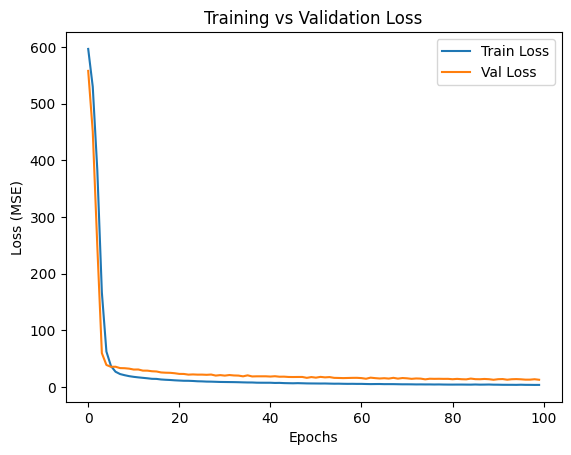

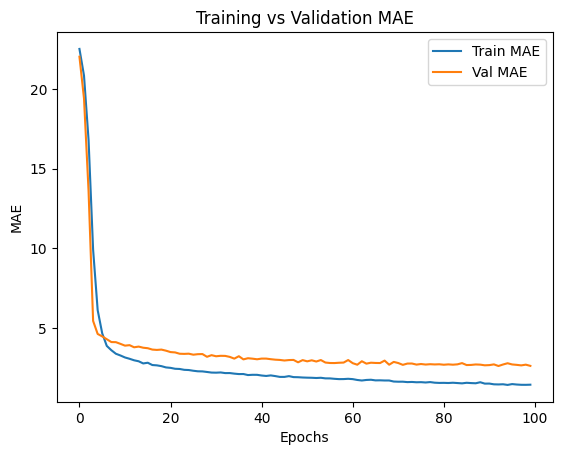

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


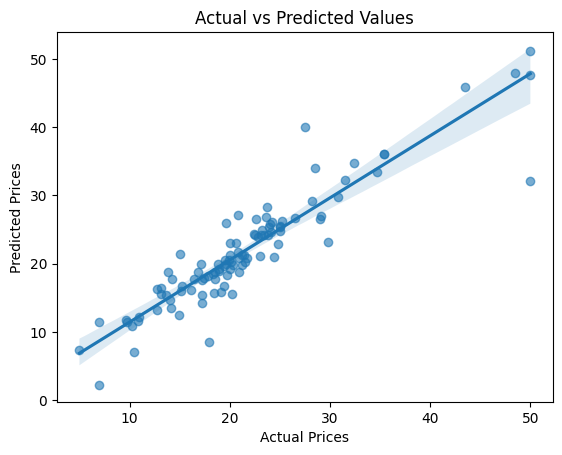

In [4]:
# -------------------------------
# 📊 GRAPH 1: Training vs Validation Loss
# -------------------------------
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# -------------------------------
# 📊 GRAPH 2: Training vs Validation MAE
# -------------------------------
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Training vs Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

# -------------------------------
# 📉 GRAPH 3: Actual vs Predicted
# -------------------------------
y_pred = model.predict(X_test)

sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6})
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Values")
plt.show()